In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import librosa
import soundfile as sf
from pydub import AudioSegment
import av

# Cấu hình hiển thị đồ thị
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True

# Tạo các thư mục lưu output nếu chưa tồn tại
os.makedirs('figures', exist_ok=True)
os.makedirs('audio', exist_ok=True)

print(" Khởi tạo thư viện và thư mục thành công!")

 Khởi tạo thư viện và thư mục thành công!


--- THÔNG TIN TỆP ÂM THANH ---
File: audio/audio1.m4a
Sampling Rate (Fs): 48000 Hz
Thời lượng: 16.747 giây
Số mẫu (N): 803840
Peak Amplitude: 0.1296
RMS Energy: 0.0199 (-34.04 dBFS)
Năng lượng tổng: 317.33


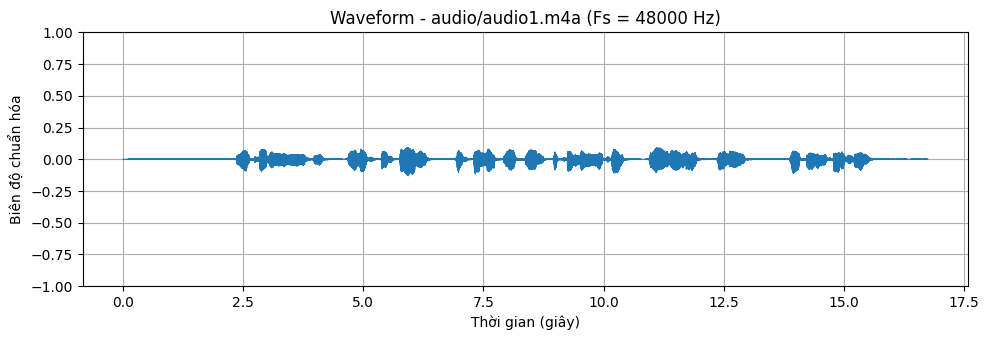

In [8]:
audio_path = 'audio/audio1.m4a'

# 1. Giải mã tệp m4a bằng PyAV
container = av.open(audio_path)
stream = container.streams.audio[0]

Fs = stream.rate
samples = []

# Đọc từng frame âm thanh và chuyển về float [-1.0, 1.0]
for frame in container.decode(stream):
    # Trình giải mã tự động gom thành mảng numpy
    frame_samples = frame.to_ndarray()
    
    # Nếu tệp là Stereo (2 kênh), lấy trung bình để chuyển thành Mono
    if frame_samples.ndim > 1 and frame_samples.shape[0] > 1:
        frame_samples = np.mean(frame_samples, axis=0)
    elif frame_samples.ndim > 1:
        frame_samples = frame_samples.squeeze()
        
    samples.append(frame_samples)

# Ghép toàn bộ mẫu tín hiệu
x = np.concatenate(samples).astype(np.float32)

# Chuẩn hóa nếu biên độ mẫu lớn hơn 1.0
if np.max(np.abs(x)) > 1.0:
    x = x / np.max(np.abs(x))

# 2. Tính toán các thông số miền thời gian
duration = len(x) / Fs
peak = np.max(np.abs(x))
rms = np.sqrt(np.mean(x**2))
energy = np.sum(x**2)

print(f"--- THÔNG TIN TỆP ÂM THANH ---")
print(f"File: {audio_path}")
print(f"Sampling Rate (Fs): {Fs} Hz")
print(f"Thời lượng: {duration:.3f} giây")
print(f"Số mẫu (N): {len(x)}")
print(f"Peak Amplitude: {peak:.4f}")
print(f"RMS Energy: {rms:.4f} ({20*np.log10(rms+1e-12):.2f} dBFS)")
print(f"Năng lượng tổng: {energy:.2f}")

# 3. Vẽ Waveform
plt.figure(figsize=(10, 3.5))
time_axis = np.linspace(0, duration, len(x))
plt.plot(time_axis, x, color='#1f77b4', linewidth=0.8)
plt.title(f"Waveform - {audio_path} (Fs = {Fs} Hz)")
plt.xlabel("Thời gian (giây)")
plt.ylabel("Biên độ chuẩn hóa")
plt.ylim(-1.0, 1.0)
plt.tight_layout()
plt.savefig('figures/waveform.png', dpi=300)
plt.show()

--- PHÂN TÍCH FFT ---
Đoạn quan sát: 2.0s -> 2.5s
NFFT: 32768 | Bin spacing (Δf): 1.465 Hz


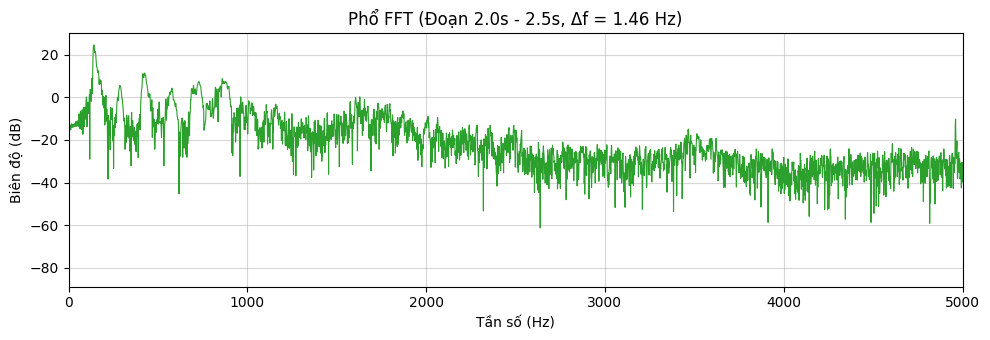

In [10]:
# Chọn đoạn ngắn 0.5 giây ở giữa tệp để thấy rõ đặc tính tần số
start_sec = 2.0  # Thời điểm bắt đầu (giây)
dur_sec = 0.5    # Thời lượng cắt (0.5 giây)

start_idx = int(start_sec * Fs)
end_idx = min(len(x), int((start_sec + dur_sec) * Fs))
seg = x[start_idx:end_idx]

# Áp dụng cửa sổ Hamming và tính FFT
w = np.hamming(len(seg))
NFFT = 32768
X = np.fft.rfft(seg * w, n=NFFT)
f = np.fft.rfftfreq(NFFT, 1/Fs)
mag_db = 20 * np.log10(np.maximum(np.abs(X), 1e-12))

df = Fs / NFFT
print(f"--- PHÂN TÍCH FFT ---")
print(f"Đoạn quan sát: {start_sec}s -> {start_sec + dur_sec}s")
print(f"NFFT: {NFFT} | Bin spacing (Δf): {df:.3f} Hz")

# Vẽ Phổ FFT (Giới hạn dải tần số 0 - 5000 Hz để nhìn rõ nét nhất)
plt.figure(figsize=(10, 3.5))
plt.plot(f, mag_db, color='#2ca02c', linewidth=0.8)
plt.title(f"Phổ FFT (Đoạn {start_sec}s - {start_sec + dur_sec}s, Δf = {df:.2f} Hz)")
plt.xlabel("Tần số (Hz)")
plt.ylabel("Biên độ (dB)")
plt.xlim(0, 5000) # Phóng to dải tần giọng nói người
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.savefig('figures/fft_spectrum.png', dpi=300)
plt.show()

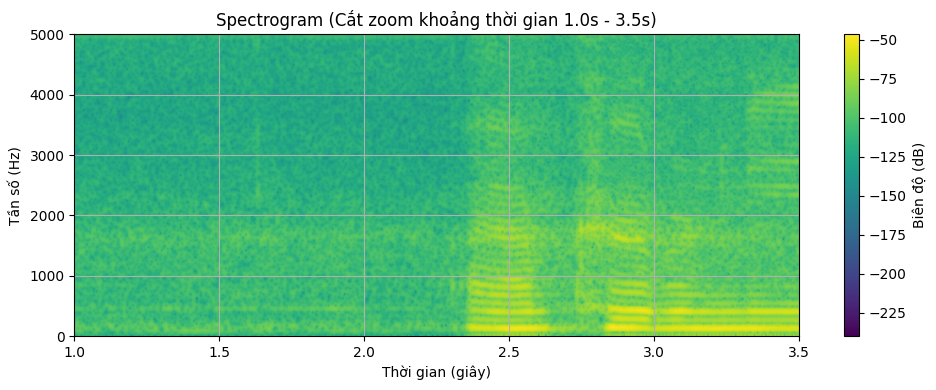

In [11]:
from scipy import signal

# Cấu hình STFT
win_ms = 25
hop_ms = 5 # Giảm Hop size xuống 5ms để ảnh mịn và rõ nét hơn
L = int(win_ms * 1e-3 * Fs)
H = int(hop_ms * 1e-3 * Fs)

f_spec, t_spec, Sxx = signal.spectrogram(
    x, fs=Fs, window='hamming',
    nperseg=L, noverlap=L-H, nfft=2048, mode='magnitude'
)
S_db = 20 * np.log10(np.maximum(Sxx, 1e-12))

# Vẽ Spectrogram thu hẹp khoảng thời gian (Ví dụ từ giây 1.0 đến giây 3.5)
plt.figure(figsize=(10, 4))
plt.pcolormesh(t_spec, f_spec, S_db, shading='gouraud', cmap='viridis')
plt.title("Spectrogram (Cắt zoom khoảng thời gian 1.0s - 3.5s)")
plt.xlabel("Thời gian (giây)")
plt.ylabel("Tần số (Hz)")
plt.xlim(1.0, 3.5)  # Zoom-in thời gian từ 1.0s đến 3.5s
plt.ylim(0, 5000)   # Tập trung dải tần giọng nói 0 - 5000 Hz
plt.colorbar(label="Biên độ (dB)")
plt.tight_layout()
plt.savefig('figures/spectrogram.png', dpi=300)
plt.show()

--- THÔNG SỐ BỘ LỌC FIR LOW-PASS ---
Tần số cắt (Cutoff): 2000 Hz
Số lượng Taps: 201
Độ trễ nhóm (Group Delay): 100.0 mẫu (~2.08 ms)
Đã lưu tệp âm thanh sau khi lọc: audio/filtered_lpf2k.wav


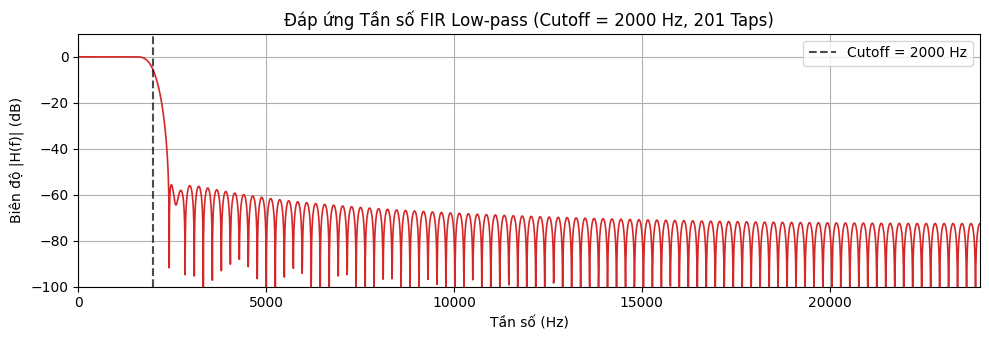

In [12]:
from scipy import signal
import soundfile as sf

# 1. Thiết kế bộ lọc FIR Low-Pass với fc = 2000 Hz, 201 taps
cutoff = 2000
numtaps = 201
b = signal.firwin(numtaps, cutoff=cutoff, fs=Fs, window='hamming')

# 2. Lọc tín hiệu âm thanh
y_lpf = signal.lfilter(b, [1.0], x)

# 3. Tính độ trễ nhóm (Group delay)
group_delay = (numtaps - 1) / 2
delay_ms = (group_delay / Fs) * 1000

print(f"--- THÔNG SỐ BỘ LỌC FIR LOW-PASS ---")
print(f"Tần số cắt (Cutoff): {cutoff} Hz")
print(f"Số lượng Taps: {numtaps}")
print(f"Độ trễ nhóm (Group Delay): {group_delay:.1f} mẫu (~{delay_ms:.2f} ms)")

# 4. Lưu file audio sau khi lọc vào thư mục audio/
filtered_path = 'audio/filtered_lpf2k.wav'
sf.write(filtered_path, y_lpf, Fs)
print(f"Đã lưu tệp âm thanh sau khi lọc: {filtered_path}")

# 5. Vẽ Đáp ứng Tần số |H(f)|
w_freq, h_freq = signal.freqz(b, worN=4096, fs=Fs)

plt.figure(figsize=(10, 3.5))
plt.plot(w_freq, 20 * np.log10(np.maximum(np.abs(h_freq), 1e-12)), color='#d62728', linewidth=1.2)
plt.title(f"Đáp ứng Tần số FIR Low-pass (Cutoff = {cutoff} Hz, {numtaps} Taps)")
plt.xlabel("Tần số (Hz)")
plt.ylabel("Biên độ |H(f)| (dB)")
plt.xlim(0, Fs / 2)
plt.ylim(-100, 10)
plt.axvline(x=cutoff, color='black', linestyle='--', alpha=0.7, label=f'Cutoff = {cutoff} Hz')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('figures/filter_response.png', dpi=300)
plt.show()

--- KẾT QUẢ LƯỢNG TỬ HÓA & SNR ---
Độ phân giải B =  4 bits | SNR đo được:   0.34 dB
Độ phân giải B =  6 bits | SNR đo được:   9.82 dB
Độ phân giải B =  8 bits | SNR đo được:  21.01 dB
Độ phân giải B = 12 bits | SNR đo được:  43.19 dB
Độ phân giải B = 16 bits | SNR đo được:  67.05 dB
Đã lưu tệp âm thanh lượng tử 8-bit: audio/quantized_8bit.wav


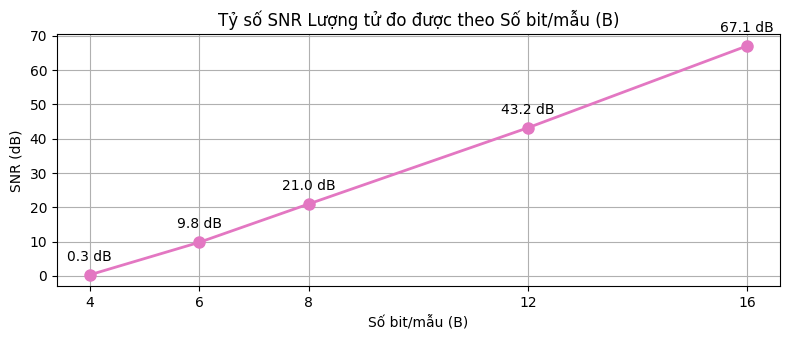

In [13]:
# Hàm lượng tử hóa tín hiệu B-bit
def quantize_signal(sig, B):
    qmax = 2**(B - 1) - 1
    xq = np.round(np.clip(sig, -1, 1) * qmax) / qmax
    e = xq - sig
    snr = 10 * np.log10(np.sum(sig**2) / np.sum(e**2 + 1e-12))
    return xq, snr

bits_list = [4, 6, 8, 12, 16]
snr_results = []

print("--- KẾT QUẢ LƯỢNG TỬ HÓA & SNR ---")
for B in bits_list:
    xq, snr_val = quantize_signal(x, B)
    snr_results.append(snr_val)
    print(f"Độ phân giải B = {B:2d} bits | SNR đo được: {snr_val:6.2f} dB")
    
    # Lưu file audio 8-bit mẫu
    if B == 8:
        sf.write('audio/quantized_8bit.wav', xq, Fs)

print(f"Đã lưu tệp âm thanh lượng tử 8-bit: audio/quantized_8bit.wav")

# Vẽ đồ thị SNR phụ thuộc vào số bit B
plt.figure(figsize=(8, 3.5))
plt.plot(bits_list, snr_results, 'o-', color='#e377c2', linewidth=2, markersize=8)
for b_val, snr_val in zip(bits_list, snr_results):
    plt.annotate(f"{snr_val:.1f} dB", (b_val, snr_val), textcoords="offset points", xytext=(0, 10), ha='center')

plt.title("Tỷ số SNR Lượng tử đo được theo Số bit/mẫu (B)")
plt.xlabel("Số bit/mẫu (B)")
plt.ylabel("SNR (dB)")
plt.xticks(bits_list)
plt.grid(True)
plt.tight_layout()
plt.savefig('figures/snr_quantization.png', dpi=300)
plt.show()

--- THỐNG KÊ DUNG LƯỢNG & TỈ LỆ NÉN ---
Dung lượng PCM 16-bit lý thuyết: 1.533 MB (1607680 Bytes)
Dung lượng tệp thực tế (audio/audio1.m4a): 0.406 MB (425660 Bytes)
Tỉ lệ nén (Compression Ratio): 3.78 : 1
Mức độ tiết kiệm dung lượng: 73.52%


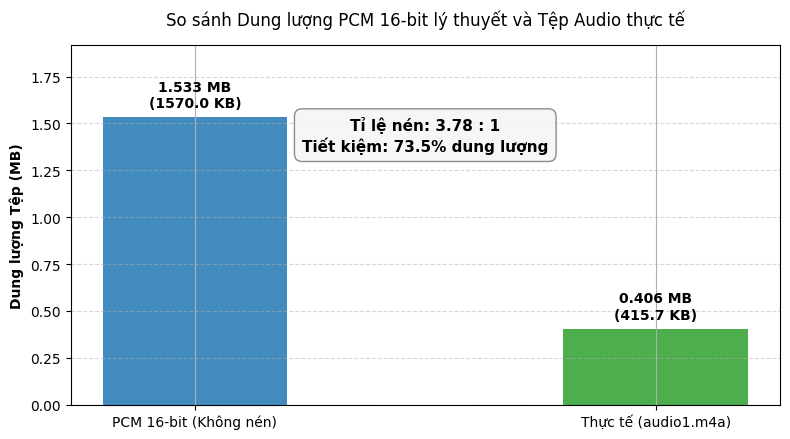

In [16]:
import os
import matplotlib.pyplot as plt

# 1. Tính toán lại dữ liệu
B_pcm = 16
C = 1  # Mono
R_pcm = Fs * B_pcm * C
size_pcm_bytes = (R_pcm * duration) / 8
size_pcm_mb = size_pcm_bytes / (1024 * 1024)

file_size_bytes = os.path.getsize(audio_path)
file_size_mb = file_size_bytes / (1024 * 1024)
compression_ratio = size_pcm_bytes / file_size_bytes
savings = (1 - 1 / compression_ratio) * 100

# In thống kê ra màn hình
print("--- THỐNG KÊ DUNG LƯỢNG & TỈ LỆ NÉN ---")
print(f"Dung lượng PCM 16-bit lý thuyết: {size_pcm_mb:.3f} MB ({size_pcm_bytes:.0f} Bytes)")
print(f"Dung lượng tệp thực tế ({audio_path}): {file_size_mb:.3f} MB ({file_size_bytes:.0f} Bytes)")
print(f"Tỉ lệ nén (Compression Ratio): {compression_ratio:.2f} : 1")
print(f"Mức độ tiết kiệm dung lượng: {savings:.2f}%")

# 2. Vẽ biểu đồ cột so sánh dung lượng trực tiếp
fig, ax = plt.subplots(figsize=(8, 4.5))

categories = ['PCM 16-bit (Không nén)', f'Thực tế ({os.path.basename(audio_path)})']
sizes = [size_pcm_mb, file_size_mb]
colors = ['#1f77b4', '#2ca02c']

bars = ax.bar(categories, sizes, color=colors, width=0.4, alpha=0.85)

# Hiển thị số liệu chi tiết trên đỉnh cột
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.3f} MB\n({height*1024:.1f} KB)',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),  # 5 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontweight='bold')

# Bổ sung thông tin tỉ lệ nén trực tiếp lên biểu đồ
ax.text(0.5, 0.75, f"Tỉ lệ nén: {compression_ratio:.2f} : 1\nTiết kiệm: {savings:.1f}% dung lượng",
        transform=ax.transAxes, fontsize=11, fontweight='bold',
        ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='whitesmoke', edgecolor='gray', alpha=0.9))

ax.set_ylabel('Dung lượng Tệp (MB)', fontweight='bold')
ax.set_title('So sánh Dung lượng PCM 16-bit lý thuyết và Tệp Audio thực tế', pad=15)
ax.set_ylim(0, max(sizes) * 1.25)
ax.grid(True, linestyle='--', alpha=0.5, axis='y')

plt.tight_layout()
plt.savefig('figures/file_size_comparison.png', dpi=300)
plt.show()